In [2]:
import h5py
import numpy as np
CRYSTAL = h5py.File('EELS_3D-out/EELS_3D_CRYSTAL_PML_a36-r245-ex.h5')
EMPTY = h5py.File('EELS_3D-out/EELS_3D_EMPTY_PML_a36-ex.h5')

In [3]:
q_e = 1.60217646e-19

In [4]:
Esim_crystal    = CRYSTAL['ex']     # NOT normalized E field in MEEP units
FLUXsim_crystal = CRYSTAL['flux']   # Electric field flux in MEEP units
Esim_empty      = EMPTY['ex']       # NOT normalized E field in MEEP units
FLUXsim_empty   = EMPTY['flux']     # Electric field flux in MEEP units

In [5]:
crystal = Esim_crystal[()]
empty   = Esim_empty[()]

In [6]:
# Normalization factor alpha
alpha_crystal = -q_e/FLUXsim_crystal[()]
alpha_empty   = -q_e/FLUXsim_empty[()]

crystal = alpha_crystal*Esim_crystal[()]    # Electric field for 1 electron in MEEP units
empty   = alpha_empty*Esim_empty[()]        # Electric field for 1 electron in MEEP units

In [7]:
crystal

array([[ 1.77188700e-18,  1.91849816e-18,  1.87265639e-18, ...,
        -5.38740572e-20, -4.76452559e-20, -4.89864079e-20],
       [-1.91358086e-18, -7.85969806e-19,  9.36352977e-19, ...,
         8.70156578e-20,  7.99046343e-20,  7.65000773e-20],
       [-1.32130838e-18, -1.68048556e-18, -2.41891805e-18, ...,
         4.60081348e-20,  4.41505352e-20,  5.42319345e-20],
       ...,
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
         1.93224057e-18,  2.02893546e-18,  2.10260829e-18],
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
        -1.18628313e-18,  1.82999561e-19,  1.41863915e-18],
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
        -1.43960448e-18, -1.95624998e-18, -2.33827445e-18]],
      shape=(866, 3152))

In [8]:
empty

array([[ 1.80400114e-18,  1.94881745e-18,  1.91015940e-18, ...,
        -5.70733667e-20, -5.63229861e-20, -5.98885185e-20],
       [-1.88307034e-18, -7.59948195e-19,  9.47681740e-19, ...,
         7.81289518e-20,  7.70452484e-20,  8.18516899e-20],
       [-1.35078433e-18, -1.70049468e-18, -2.41873713e-18, ...,
         5.60196725e-20,  5.52911199e-20,  5.88035205e-20],
       ...,
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
         1.89314207e-18,  1.99239815e-18,  2.06512124e-18],
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
        -1.24528761e-18,  1.10647648e-19,  1.32048182e-18],
       [-0.00000000e+00, -0.00000000e+00, -0.00000000e+00, ...,
        -1.54852770e-18, -2.05229729e-18, -2.42766143e-18]],
      shape=(866, 3152))

In [9]:
diff = crystal - empty  # Eind in MEEP units
diff

array([[-3.21141313e-20, -3.03192952e-20, -3.75030112e-20, ...,
         3.19930942e-21,  8.67773014e-21,  1.09021106e-20],
       [-3.05105243e-20, -2.60216101e-20, -1.13287633e-20, ...,
         8.88670605e-21,  2.85938598e-21, -5.35161256e-21],
       [ 2.94759471e-20,  2.00091176e-20, -1.80915838e-22, ...,
        -1.00115377e-20, -1.11405847e-20, -4.57158600e-21],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         3.90984942e-20,  3.65373140e-20,  3.74870517e-20],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         5.90044773e-20,  7.23519128e-20,  9.81573315e-20],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         1.08923220e-19,  9.60473075e-20,  8.93869784e-20]],
      shape=(866, 3152))

In [10]:
with h5py.File("crystal_PML_a36-r245-ex.hdf5", "w") as f:
    dset = f.create_dataset("ex", empty.shape, dtype='<f8', data=crystal)

In [11]:
with h5py.File("empty_PML_a36-ex.hdf5", "w") as f:
    dset = f.create_dataset("ex", crystal.shape, dtype='<f8', data=empty)

In [12]:
with h5py.File("diff_PML_a36-r245.hdf5", "w") as f:
    dset = f.create_dataset("ex", diff.shape, dtype='<f8', data=diff)

# Check how the flux changes over time

In [13]:
import matplotlib.pyplot as plt

In [15]:
t = np.arange(0,len(FLUXsim_crystal))

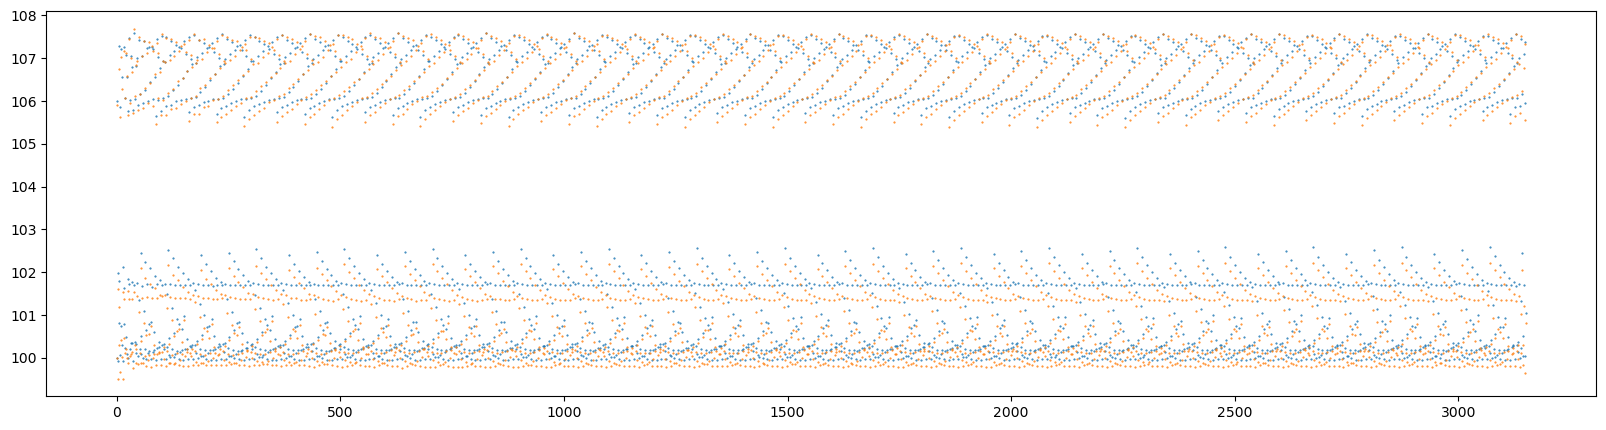

In [35]:
plt.figure(figsize=(20,5))
plt.plot(t, FLUXsim_empty[()]/FLUXsim_empty[0]*100, '.', ms=1)
plt.plot(t, FLUXsim_crystal[()]/FLUXsim_crystal[0]*100, '.', ms=1)